In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 


In [3]:
df = pd.read_csv('ushape.csv')
df.sample(5)

,X,Y,class
14,0.467308,0.547032,0.0
83,-0.875394,0.505434,0.0
55,0.195363,0.160851,1.0
73,2.022971,0.123251,1.0
40,1.520021,-0.045156,0.0


In [4]:
df.shape


(100, 3)

In [12]:
X= df.iloc[:,:2]
y= df.iloc[:,-1]

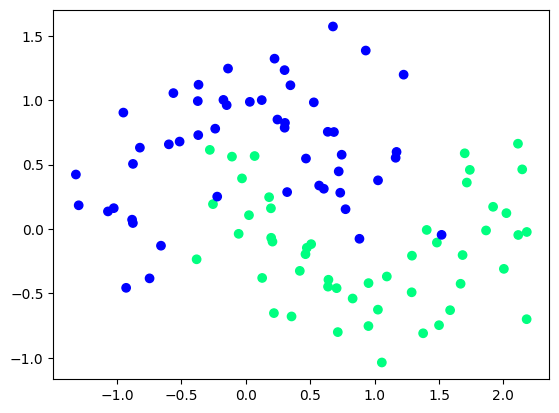

In [11]:
plt.scatter(df.iloc[:,:1],df.iloc[:,1:2],c = df.iloc[:,-1],cmap='winter')

In [14]:
from sklearn.linear_model import LogisticRegression 

lor = LogisticRegression() 
lor.fit(X,y)

y_pred = lor.predict(X)

In [39]:
from sklearn.metrics import classification_report,confusion_matrix

print(classification_report(y,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.84      0.84        50
           1       0.84      0.84      0.84        50

    accuracy                           0.84       100
   macro avg       0.84      0.84      0.84       100
weighted avg       0.84      0.84      0.84       100



C:\Users\HP Laptop 15\tfenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


<Axes: >

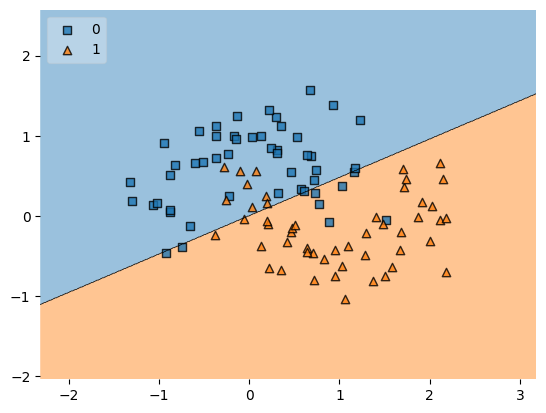

In [27]:
from mlxtend.plotting import plot_decision_regions 

plot_decision_regions(df.iloc[:,:2].values,y.values.astype(int).ravel() , clf= lor,legend= 2)

# Let's use polynomial features 

In [42]:
from sklearn.preprocessing import PolynomialFeatures 

X = df.iloc[:, :2].values   
y = df.iloc[:, -1].values.astype(int)


def polynomial_lor(X,y, degree = 1): 
    poly = PolynomialFeatures(degree = degree) 
    X_trf = poly.fit_transform(X)
    lorr = LogisticRegression() 
    lorr.fit(X_trf,y) 
    y_predd = lorr.predict(X_trf) 

    x_min, x_max = X[:,0].min() - 1, X[:,1].max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    
    xx, yy = np.meshgrid( np.linspace(x_min, x_max, 100),
                        np.linspace(y_min, y_max, 100))
    
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_trf = poly.transform(grid)

    Z = lorr.predict(grid_trf)
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='winter')
    plt.scatter(df.iloc[:,:1],df.iloc[:,1:2],c = df.iloc[:,-1],cmap='winter')
    plt.show() 
    print('Classification Report:',classification_report(y,y_predd))
    print('Confusion Matrix: ','\n' ,confusion_matrix(y_predd,y))
    
    

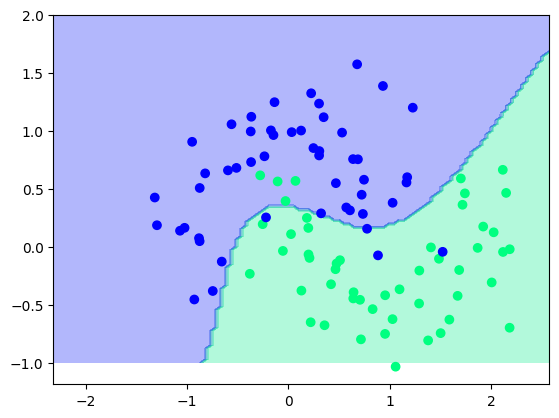

Classification Report:               precision    recall  f1-score   support

           0       0.92      0.92      0.92        50
           1       0.92      0.92      0.92        50

    accuracy                           0.92       100
   macro avg       0.92      0.92      0.92       100
weighted avg       0.92      0.92      0.92       100

Confusion Matrix:  
 [[46  4]
 [ 4 46]]


In [45]:
polynomial_lor(X,y,3)

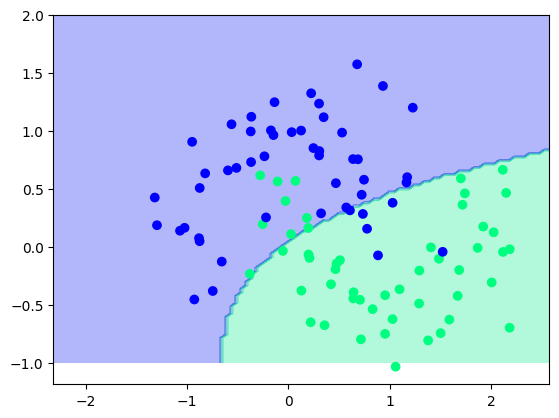

Classification Report:               precision    recall  f1-score   support

           0       0.83      0.88      0.85        50
           1       0.87      0.82      0.85        50

    accuracy                           0.85       100
   macro avg       0.85      0.85      0.85       100
weighted avg       0.85      0.85      0.85       100

Confusion Matrix:  
 [[44  9]
 [ 6 41]]


In [46]:
polynomial_lor(X,y,2)

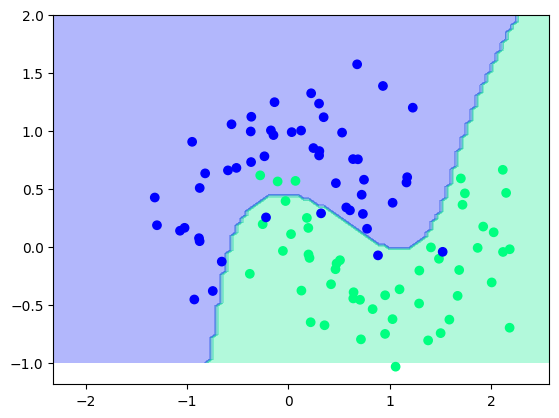

Classification Report:               precision    recall  f1-score   support

           0       0.94      0.92      0.93        50
           1       0.92      0.94      0.93        50

    accuracy                           0.93       100
   macro avg       0.93      0.93      0.93       100
weighted avg       0.93      0.93      0.93       100

Confusion Matrix:  
 [[46  3]
 [ 4 47]]


In [47]:
polynomial_lor(X,y,5)

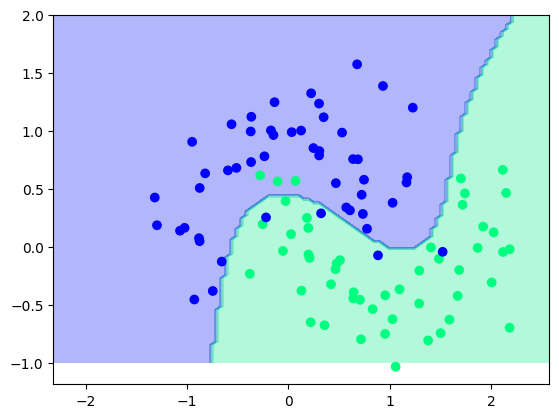

Classification Report:               precision    recall  f1-score   support

           0       0.94      0.92      0.93        50
           1       0.92      0.94      0.93        50

    accuracy                           0.93       100
   macro avg       0.93      0.93      0.93       100
weighted avg       0.93      0.93      0.93       100

Confusion Matrix:  
 [[46  3]
 [ 4 47]]


In [48]:
polynomial_lor(X,y,6)

C:\Users\HP Laptop 15\tfenv\lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


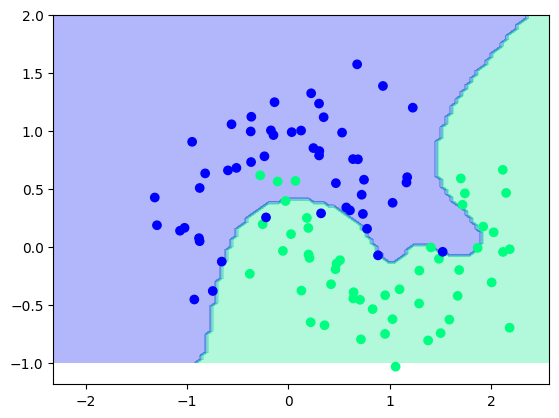

Classification Report:               precision    recall  f1-score   support

           0       0.94      0.94      0.94        50
           1       0.94      0.94      0.94        50

    accuracy                           0.94       100
   macro avg       0.94      0.94      0.94       100
weighted avg       0.94      0.94      0.94       100

Confusion Matrix:  
 [[47  3]
 [ 3 47]]


In [53]:
polynomial_lor(X,y,27)